# Map integration

In [16]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import networkx as nx

In [17]:
edges = pd.read_csv("../data/edges.csv").rename(columns=lambda x: x.strip())[["# source", "target", "distance"]].drop_duplicates()
nodes = pd.read_csv("../data/nodes.csv").rename(columns=lambda x: x.strip())
nodes = nodes[["name","city","country","latitude","longitude"]]

In [18]:
nodes.head()

,name,city,country,latitude,longitude
0,Goroka Airport,Goroka,Papua New Guinea,-6.081690,145.391998
1,Madang Airport,Madang,Papua New Guinea,-5.207080,145.789001
2,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,-5.826790,144.296005
3,Nadzab Airport,Nadzab,Papua New Guinea,-6.569803,146.725977
4,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,-9.443380,147.220001


In [19]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radius of the Earth in km
    
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    # Haversine formula
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

In [21]:
# edges["route"] = edges[["# source", "target"]].apply(lambda row: (row["# source"], row["target"]), axis=1)
# not_bridge_edges = edges[edges["route"].apply(lambda x: x not in bridges)]
# bridge_edges = edges[edges["route"].apply(lambda x: x in bridges)]

In [22]:
edges.columns

Index(['# source', 'target', 'distance'], dtype='str')

In [23]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

for source, target, distance in edges.values:
    A[np.int16(source)][np.int16(target)] = distance

# Porovnanie s náhodnými modelmi

In [40]:
G_real = nx.from_numpy_array(A, create_using=nx.DiGraph)

In [41]:
G_real = nx.from_pandas_edgelist(edges, source='# source', target='target', create_using=nx.DiGraph).to_undirected()

# Zistíme základné parametre
N = G_real.number_of_nodes()
M = G_real.number_of_edges()

print(f"Reálna sieť má {N} vrcholov a {M} hrán.")

Reálna sieť má 3214 vrcholov a 18859 hrán.


In [42]:
# --- 1. Erdős–Rényi (ER) ---
# Vypočítame pravdepodobnosť 'p' tak, aby sme mali v priemere rovnaký počet hrán M.
# Maximálny možný počet hrán je N * (N - 1) / 2.
p = (2 * M) / (N * (N - 1))

G_er = nx.erdos_renyi_graph(n=N, p=p, seed=42)
print(f"ER graf vygenerovaný: {G_er.number_of_edges()} hrán.")


# --- 2. Barabási–Albert (BA) ---
# Parameter 'm' určuje, koľko hrán vytvorí každý nový vrchol pri pridaní do siete.
# Keďže každý vrchol pridá 'm' hrán, celkový počet hrán bude zhruba N * m.
# Preto m vypočítame ako M / N (zaokrúhlené na celé číslo).
m = int(round(M / N))

# Poistka, BA model vyžaduje aby m >= 1 a m < N
if m < 1: m = 1 

G_ba = nx.barabasi_albert_graph(n=N, m=m, seed=42)
print(f"BA graf vygenerovaný: {G_ba.number_of_edges()} hrán.")

ER graf vygenerovaný: 18642 hrán.
BA graf vygenerovaný: 19248 hrán.


In [43]:
def vypocitaj_statistiku(G, nazov_siete):
    print(f"\n--- Štatistika pre: {nazov_siete} ---")
    
    # 1. Priemerný zhlukový koeficient (Clustering Coefficient)
    # Meria, aká je šanca, že ak A letí do B a A letí do C, tak existuje let aj medzi B a C.
    cc = nx.average_clustering(G)
    print(f"Zhlukový koeficient: {cc:.4f}")
    
    # 2. Priemerná najkratšia cesta
    # POZOR: Toto funguje len na súvislých grafoch! Preto si musíme zobrať 
    # len najväčší súvislý komponent (Giant Component).
    giant_component_nodes = max(nx.connected_components(G), key=len)
    G_giant = G.subgraph(giant_component_nodes)
    
    avg_path = nx.average_shortest_path_length(G_giant)
    print(f"Priemerná dĺžka najkratšej cesty: {avg_path:.4f}")

# Spustíme výpočty
vypocitaj_statistiku(G_real, "Reálna letecká sieť")
vypocitaj_statistiku(G_er, "Erdős–Rényi (Náhodný)")
vypocitaj_statistiku(G_ba, "Barabási–Albert (Huby)")


--- Štatistika pre: Reálna letecká sieť ---
Zhlukový koeficient: 0.4918
Priemerná dĺžka najkratšej cesty: 3.9585

--- Štatistika pre: Erdős–Rényi (Náhodný) ---
Zhlukový koeficient: 0.0041
Priemerná dĺžka najkratšej cesty: 3.5708

--- Štatistika pre: Barabási–Albert (Huby) ---
Zhlukový koeficient: 0.0201
Priemerná dĺžka najkratšej cesty: 3.1644


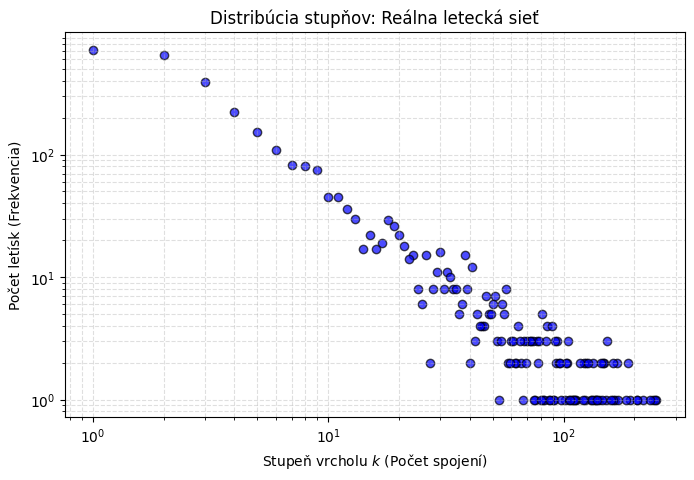

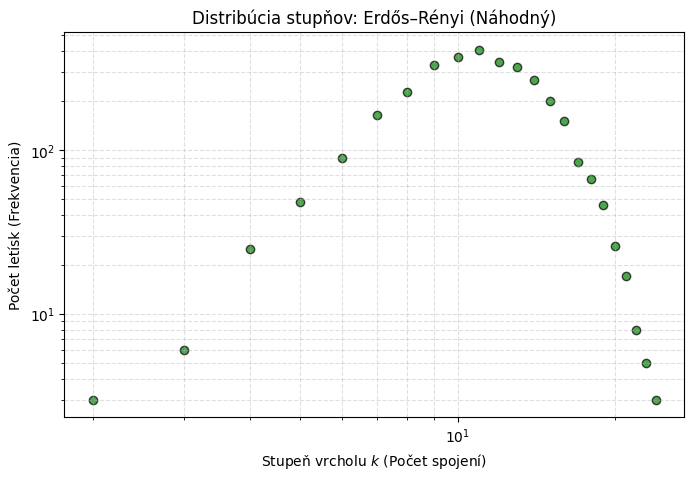

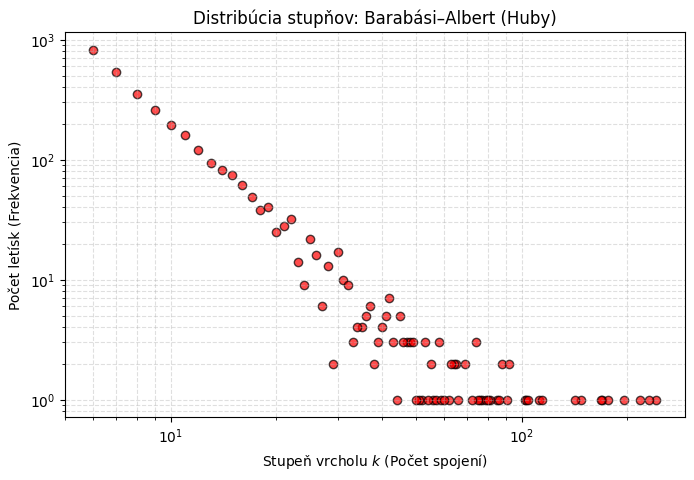

In [48]:
import matplotlib.pyplot as plt
from collections import Counter

def vykresli_distribuciu_stupnov(G, nazov_siete, farba):
    # 1. Získame zoznam stupňov pre všetky vrcholy v grafe
    stupne = [G.degree(n) for n in G.nodes()]
    
    # 2. Spočítame, koľko letísk má aký stupeň (napr. koľko letísk má presne 1 let, 2 lety, atď.)
    pocetnost_stupnov = Counter(stupne)
    
    # Rozdelíme to na os X (stupeň) a os Y (počet letísk s týmto stupňom)
    x = list(pocetnost_stupnov.keys())
    y = list(pocetnost_stupnov.values())
    
    # 3. Vykreslenie
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color=farba, alpha=0.7, edgecolors="black")
    
    plt.title(f"Distribúcia stupňov: {nazov_siete}")
    plt.xlabel("Stupeň vrcholu $k$ (Počet spojení)")
    plt.ylabel("Počet letísk (Frekvencia)")
    
    # Nastavenie logaritmickej mierky (kľúčové pre scale-free siete)
    plt.xscale('log')
    plt.yscale('log')
    
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.show()

# Vykreslíme grafy pre všetky tri siete, ktoré sme si predtým vygenerovali
vykresli_distribuciu_stupnov(G_real, "Reálna letecká sieť", "blue")
vykresli_distribuciu_stupnov(G_er, "Erdős–Rényi (Náhodný)", "green")
vykresli_distribuciu_stupnov(G_ba, "Barabási–Albert (Huby)", "red")

In [ ]:
# 1. Získame presnú postupnosť stupňov (degree sequence) z vašej reálnej siete
# Vráti zoznam čísel, napr. [1, 5, 2, 10, ...]
postupnost_stupnov = [stupen for vrchol, stupen in G_real.degree()]

# 2. Vygenerujeme konfiguračný model
# Výsledkom je MultiGraph (môže obsahovať slučky a násobné hrany)
G_conf_multi = nx.configuration_model(postupnost_stupnov, seed=42)

# 3. Prevedieme MultiGraph na obyčajný Graph (odstráni násobné hrany)
G_conf = nx.Graph(G_conf_multi)

# 4. Odstránime slučky (self-loops)
G_conf.remove_edges_from(nx.selfloop_edges(G_conf))

print(f"Počet hrán - Reálna sieť: {G_real.number_of_edges()}")
print(f"Počet hrán - Konfiguračný model: {G_conf.number_of_edges()}")
vypocitaj_statistiku(G_conf, "Konfiguračný model")

Počet hrán - Reálna sieť: 18859
Počet hrán - Konfiguračný model: 17893

--- Štatistika pre: Konfiguračný model ---
Zhlukový koeficient: 0.0732
Priemerná dĺžka najkratšej cesty: 3.3343
